In [ ]:
import numpy as np
import pandas as pd

def make_portfolio_dataset(
    n: int = 50_000,
    start_date: str = '2020-01',
    end_date: str   = '2024-12',
    target_event_rate: float = 0.08,
    random_state: int = 42,
) -> pd.DataFrame:

    rng   = np.random.default_rng(random_state)
    meses = pd.period_range(start_date, end_date, freq='M')
    w     = np.linspace(0.5, 1.5, len(meses))
    w    /= w.sum()

    safras        = meses[rng.choice(len(meses), size=n, p=w)].astype(str)
    seg_map       = np.array(['leves','pesados','motos','outros'])
    segmento      = seg_map[rng.choice(4, n, p=[0.50,0.20,0.20,0.10])]
    prazo_meses   = rng.choice([12,24,36,48,60], n, p=[0.05,0.15,0.35,0.35,0.10])
    score_quod    = np.clip(rng.normal(650, 80, n), 300, 900).round(0).astype(int)
    renda_media   = np.where(segmento=='pesados', 9.0,
                    np.where(segmento=='motos',   7.8,
                    np.where(segmento=='outros',  8.0, 8.4)))
    renda     = np.round(np.exp(rng.normal(renda_media, 0.5, n)), 2)
    idade_cliente = np.clip(rng.normal(38, 10, n), 18, 75).round(0).astype(int)
    uf_map        = np.array(['SP','MG','RJ','PR','RS','BA','SC','GO','PE','MT'])
    uf_bem        = uf_map[rng.choice(10, n, p=[0.28,0.14,0.12,0.10,0.09,0.07,0.07,0.05,0.05,0.03])]
    idade_veic    = np.clip(rng.poisson(4, n), 0, 15).astype(int)
    noise         = rng.normal(0, 0.4, n)
    u             = rng.weibull(1.4, n)

    # sinais orientados para exp(lp_base) como escala (positivo = mais sobrevivência)
    risco_seg = np.where(segmento=='motos',   -0.6,
                np.where(segmento=='pesados', +0.2,
                np.where(segmento=='outros',  -0.1, 0.0)))
    risco_uf  = np.where(np.isin(uf_bem, ['BA','PE','MT']),  -0.25,
                np.where(np.isin(uf_bem, ['SP','RS','SC']),  +0.10, 0.0))

    lp_base = (
        +0.5  * (score_quod / 650)
        +0.4  * np.log(renda / 4500)
        -0.3  * (prazo_meses / 36)
        -0.25 * (idade_veic / 5)
        +risco_seg + risco_uf + noise
    )

    cutoff   = pd.Period(end_date, freq='M')
    mobs_obs = np.array([int((cutoff - pd.Period(s, freq='M')).n) for s in safras])
    t_cens   = np.maximum(np.minimum(prazo_meses, mobs_obs).astype(float), 1)

    lo, hi = -10.0, 10.0
    for _ in range(60):
        mid      = (lo + hi) / 2
        t_try    = u * np.exp(lp_base + mid) * 24
        rate_try = (t_try <= t_cens).mean()
        if rate_try > target_event_rate:
            lo = mid
        else:
            hi = mid

    intercept = (lo + hi) / 2
    t_event   = u * np.exp(lp_base + intercept) * 24

    t_default     = np.clip(np.round(np.minimum(t_event, t_cens)).astype(int), 1, 60)
    event_default = (t_event <= t_cens).astype(int)

    df = pd.DataFrame({
        'no_contrato'  : [f'CTR{i:08d}' for i in range(n)],
        'ano_mes'      : safras,
        'segmento'     : segmento,
        'prazo_meses'  : prazo_meses,
        'score_quod'   : score_quod,
        'renda'    : renda,
        'uf_bem'       : uf_bem,
        'idade_veic'   : idade_veic,
        'idade_cliente': idade_cliente,
        't_default'    : t_default,
        'event_default': event_default,
    })

    print(f"Target rate    : {target_event_rate:.1%}")
    print(f"Event rate real: {df.event_default.mean():.1%}")
    print(f"T mediano      : {df.t_default.median():.0f} meses")
    print(f"Intercepto     : {intercept:.4f}")
    print(f"\nGabarito esperado: motos > leves > outros > pesados")
    print(f"\nSegmento:")
    print(df.groupby('segmento').agg(
        n         =('no_contrato',   'count'),
        n_events  =('event_default', 'sum'),
        event_rate=('event_default', 'mean'),
    ).assign(event_rate=lambda d: d.event_rate.map('{:.1%}'.format)).to_string())

    return df


df = make_portfolio_dataset(n=50_000, target_event_rate=0.08)

Target rate    : 8.0%
Event rate real: 8.0%
T mediano      : 19 meses
Intercepto     : 2.0871

Gabarito esperado: motos > leves > outros > pesados

Segmento:
              n  n_events event_rate
segmento                            
leves     24929      1555       6.2%
motos      9864      1668      16.9%
outros     5054       432       8.5%
pesados   10153       346       3.4%


split_dataset: garante que cada safra tem exatamente 80% no treino e 20% no teste, preservando a distribuição de censura. Sem isso, o treino poderia concentrar safras antigas (mais MOBs observados) e o teste safras recentes (mais censuradas), o que distorceria qualquer métrica de validação.O  max_diff mede a maior diferença de proporção entre as duas distribuições — se for próximo de zero, o split está bem balanceado.

In [22]:
from sklearn.model_selection import train_test_split

def split_dataset(
    df: pd.DataFrame,
    holdout_start: str = '2024-07',
    test_size: float   = 0.20,
    safra_col: str     = 'ano_mes',
    random_state: int  = 42,
) -> tuple:
    """
    Divide o dataset em treino, teste e holdout OOT.

    Lógica:
      - Holdout OOT  : safras >= holdout_start (separadas antes de tudo)
      - Treino/Teste : split estratificado por ano_mes dentro do in-time
                       garante mesma distribuição de safras e de censura

    Parameters
    ----------
    df             : DataFrame completo
    holdout_start  : primeira safra do holdout (ex: '2024-07')
    test_size      : fração do in-time para teste (default 20%)
    safra_col      : coluna de safra no formato 'YYYY-MM'
    random_state   : semente

    Returns
    -------
    train, test, holdout : DataFrames
    """
    mask_oot = df[safra_col] >= holdout_start
    holdout  = df[ mask_oot].copy()
    df_it    = df[~mask_oot].copy()

    train_idx, test_idx = train_test_split(
        df_it.index,
        test_size=test_size,
        stratify=df_it[safra_col],
        random_state=random_state,
    )
    train = df_it.loc[train_idx].copy()
    test  = df_it.loc[test_idx].copy()

    print(f"{'─'*55}")
    print(f"  Split do dataset")
    print(f"{'─'*55}")
    for nome, d in [('Treino', train), ('Teste', test), ('Holdout OOT', holdout)]:
        print(f"  {nome:<12}: {len(d):>6,} contratos "
              f"| default={d.event_default.mean():.1%} "
              f"| safras: {d[safra_col].min()} → {d[safra_col].max()}")
    print(f"{'─'*55}")

    # Validação: distribuição de safras igual em treino e teste
    dist_train = train[safra_col].value_counts(normalize=True).sort_index()
    dist_test  = test[safra_col].value_counts(normalize=True).sort_index()
    max_diff   = (dist_train - dist_test).abs().max()
    print(f"  Max diff de safra treino vs teste: {max_diff:.4f} "
          f"{'✅' if max_diff < 0.01 else '⚠️'}")

    return train, test, holdout


train, test, holdout = split_dataset(df, holdout_start='2024-07')

───────────────────────────────────────────────────────
  Split do dataset
───────────────────────────────────────────────────────
  Treino      : 34,215 contratos | default=9.3% | safras: 2020-01 → 2024-06
  Teste       :  8,554 contratos | default=9.2% | safras: 2020-01 → 2024-06
  Holdout OOT :  7,231 contratos | default=0.4% | safras: 2024-07 → 2024-12
───────────────────────────────────────────────────────
  Max diff de safra treino vs teste: 0.0001 ✅


Sample for analysis: sample estratificado para as etapas exploratórias e de feature selection — preservando a distribuição de safras e de evento.

In [23]:
def sample_for_analysis(
    df: pd.DataFrame,
    sample_pct: float  = 0.10,
    safra_col: str     = 'ano_mes',
    event_col: str     = 'event_default',
    random_state: int  = 42,
) -> pd.DataFrame:
    """
    Sample estratificado por ano_mes × event_default.

    Estratifica pelos dois ao mesmo tempo para garantir que:
      - Cada safra tem a mesma representação proporcional
      - A taxa de evento de cada safra é preservada no sample

    Útil para: feature selection, martingale residuals,
               log-rank screening, seleção de transformações.

    NÃO usar para: treino do modelo final (usa o dataset completo).

    Parameters
    ----------
    df           : DataFrame (normalmente o treino)
    sample_pct   : fração a amostrar (ex: 0.10 = 10%)
    safra_col    : coluna de safra
    event_col    : coluna de evento binário
    random_state : semente

    Returns
    -------
    DataFrame com sample estratificado
    """
    # Estratifica por safra × evento simultaneamente
    strat_col = df[safra_col].astype(str) + '_' + df[event_col].astype(str)

    sample = (
        df.assign(_strat=strat_col)
          .groupby('_strat', group_keys=False)
          .apply(lambda g: g.sample(
              frac=sample_pct,
              random_state=random_state,
              replace=len(g) < 5,   # só usa replace se o grupo for minúsculo
          ))
          .drop(columns='_strat')
          .reset_index(drop=True)
    )

    print(f"{'─'*55}")
    print(f"  Sample para análise")
    print(f"{'─'*55}")
    print(f"  Original  : {len(df):>7,} contratos | default={df[event_col].mean():.1%}")
    print(f"  Sample    : {len(sample):>7,} contratos | default={sample[event_col].mean():.1%}")
    print(f"  Fração    : {len(sample)/len(df):.1%}")

    # Valida que a distribuição de safras foi preservada
    dist_orig   = df[safra_col].value_counts(normalize=True).sort_index()
    dist_sample = sample[safra_col].value_counts(normalize=True).sort_index()
    max_diff    = (dist_orig - dist_sample).abs().max()
    print(f"  Max diff de safra original vs sample: {max_diff:.4f} "
          f"{'✅' if max_diff < 0.02 else '⚠️'}")
    print(f"{'─'*55}")

    return sample


# Aplica no treino — é o conjunto que usaremos para exploração
sample = sample_for_analysis(train, sample_pct=0.10)

───────────────────────────────────────────────────────
  Sample para análise
───────────────────────────────────────────────────────
  Original  :  34,215 contratos | default=9.3%
  Sample    :   3,419 contratos | default=9.2%
  Fração    : 10.0%
  Max diff de safra original vs sample: 0.0002 ✅
───────────────────────────────────────────────────────


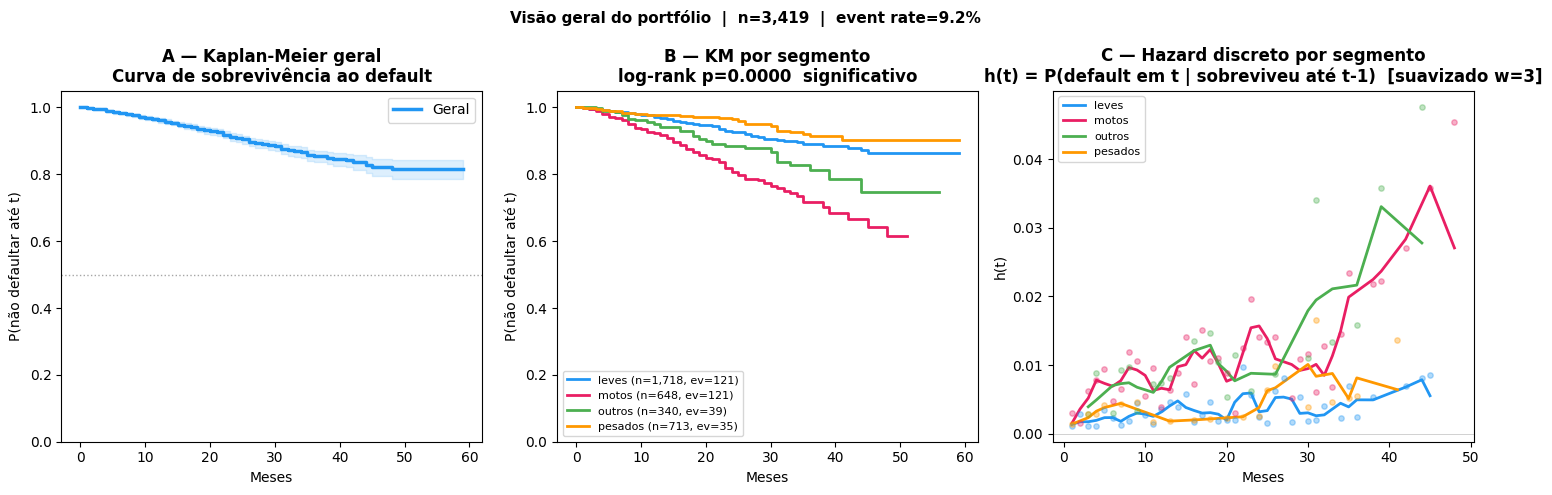

In [33]:
from lifelines import KaplanMeierFitter
from lifelines.statistics import multivariate_logrank_test
import matplotlib.pyplot as plt

def plot_km_overview(
    df: pd.DataFrame,
    time_col: str        = 't_default',
    event_col: str       = 'event_default',
    group_col: str       = 'segmento',
    smooth_window: int   = 3,
    figsize: tuple       = (15, 5),
) -> None:
    """
    Três painéis:
      A — KM geral com banda de confiança
      B — KM por grupo (group_col) com log-rank p-value
      C — Hazard discreto por grupo (suavizado)

    O hazard discreto é calculado como:
      h(t) = [S(t-1) - S(t)] / S(t-1)
    ou seja, a probabilidade de defaultar no mês t
    dado que sobreviveu até t-1.

    Parameters
    ----------
    df            : DataFrame (use o sample para datasets grandes)
    time_col      : coluna de tempo
    event_col     : coluna de evento binário
    group_col     : coluna categórica para comparação
    smooth_window : janela de média móvel no hazard discreto
    figsize       : tamanho da figura
    """
    PALETTE = ['#2196F3','#E91E63','#4CAF50','#FF9800','#9C27B0','#00BCD4']

    def discrete_hazard(kmf):
        sf   = kmf.survival_function_.iloc[:, 0].values
        h    = np.zeros(len(sf))
        for i in range(1, len(sf)):
            if sf[i-1] > 0:
                h[i] = (sf[i-1] - sf[i]) / sf[i-1]
        times = kmf.survival_function_.index.values
        mask  = h > 0
        return times[mask], h[mask]

    def smooth(x, w):
        if len(x) <= w:
            return x
        return np.convolve(x, np.ones(w)/w, mode='same')

    fig, axes = plt.subplots(1, 3, figsize=figsize)

    # ── A: KM geral ──────────────────────────────────────────────────────────
    kmf_all = KaplanMeierFitter(label='Geral')
    kmf_all.fit(df[time_col], event_observed=df[event_col])
    kmf_all.plot_survival_function(
        ax=axes[0], color='#2196F3',
        ci_show=True, ci_alpha=0.15, linewidth=2.5,
    )
    med = kmf_all.median_survival_time_
    axes[0].axhline(0.5, color='gray', linestyle=':', linewidth=1, alpha=0.7)
    axes[0].axvline(med, color='gray', linestyle=':', linewidth=1, alpha=0.7)
    axes[0].text(med + 0.3, 0.52,
                 f'mediana = {med:.0f}m', fontsize=9, color='gray')
    axes[0].set_title('A — Kaplan-Meier geral\nCurva de sobrevivência ao default',
                      fontweight='bold')
    axes[0].set_xlabel('Meses')
    axes[0].set_ylabel('P(não defaultar até t)')
    axes[0].set_ylim(0, 1.05)

    # ── B: KM por grupo ───────────────────────────────────────────────────────
    grupos = sorted(df[group_col].unique())
    for grupo, color in zip(grupos, PALETTE):
        mask = df[group_col] == grupo
        n    = mask.sum()
        ev   = df.loc[mask, event_col].sum()
        kmf  = KaplanMeierFitter(label=f'{grupo} (n={n:,}, ev={ev})')
        kmf.fit(df.loc[mask, time_col], event_observed=df.loc[mask, event_col])
        kmf.plot_survival_function(
            ax=axes[1], color=color,
            ci_show=False, linewidth=2,
        )

    lr = multivariate_logrank_test(df[time_col], df[group_col], df[event_col])
    sig = 'significativo' if lr.p_value < 0.05 else 'não significativo'
    axes[1].set_title(
        f'B — KM por {group_col}\nlog-rank p={lr.p_value:.4f}  {sig}',
        fontweight='bold',
    )
    axes[1].set_xlabel('Meses')
    axes[1].set_ylabel('P(não defaultar até t)')
    axes[1].set_ylim(0, 1.05)
    axes[1].legend(fontsize=8)

    # ── C: Hazard discreto por grupo ─────────────────────────────────────────
    for grupo, color in zip(grupos, PALETTE):
        mask = df[group_col] == grupo
        kmf  = KaplanMeierFitter()
        kmf.fit(df.loc[mask, time_col], event_observed=df.loc[mask, event_col])
        t_h, h = discrete_hazard(kmf)
        # Pontos brutos
        axes[2].scatter(t_h, h, color=color, s=15, alpha=0.35, zorder=3)
        # Linha suavizada
        if len(h) > smooth_window:
            axes[2].plot(t_h, smooth(h, smooth_window),
                         color=color, linewidth=2, label=grupo)

    axes[2].set_title(
        f'C — Hazard discreto por {group_col}\n'
        f'h(t) = P(default em t | sobreviveu até t-1)  '
        f'[suavizado w={smooth_window}]',
        fontweight='bold',
    )
    axes[2].set_xlabel('Meses')
    axes[2].set_ylabel('h(t)')
    axes[2].legend(fontsize=8)
    axes[2].axhline(0, color='gray', linewidth=0.5, alpha=0.5)

    plt.suptitle(
        f'Visão geral do portfólio  |  n={len(df):,}  |  '
        f'event rate={df[event_col].mean():.1%}',
        fontsize=11, fontweight='bold',
    )
    plt.tight_layout()
    plt.show()


plot_km_overview(sample, group_col='segmento', smooth_window=3)

A linha suavizada é uma média móvel dos pontos brutos — em vez de conectar cada ponto diretamente (o que cria uma linha muito irregular), ela calcula a média dos w pontos vizinhos em cada posição.
Com smooth_window=3, o valor em cada mês t vira a média de h(t-1), h(t) e h(t+1). O resultado é a linha contínua que você vê no painel C. Os pontos coloridos espalhados são os valores brutos antes da suavização.
O hazard discreto é inerentemente ruidoso porque nos MOBs mais longos sobram poucos contratos em risco — uma variação de 1 ou 2 eventos num risk set pequeno causa grandes oscilações. A suavização é só visual para facilitar a leitura da tendência, não muda nenhum cálculo do modelo.

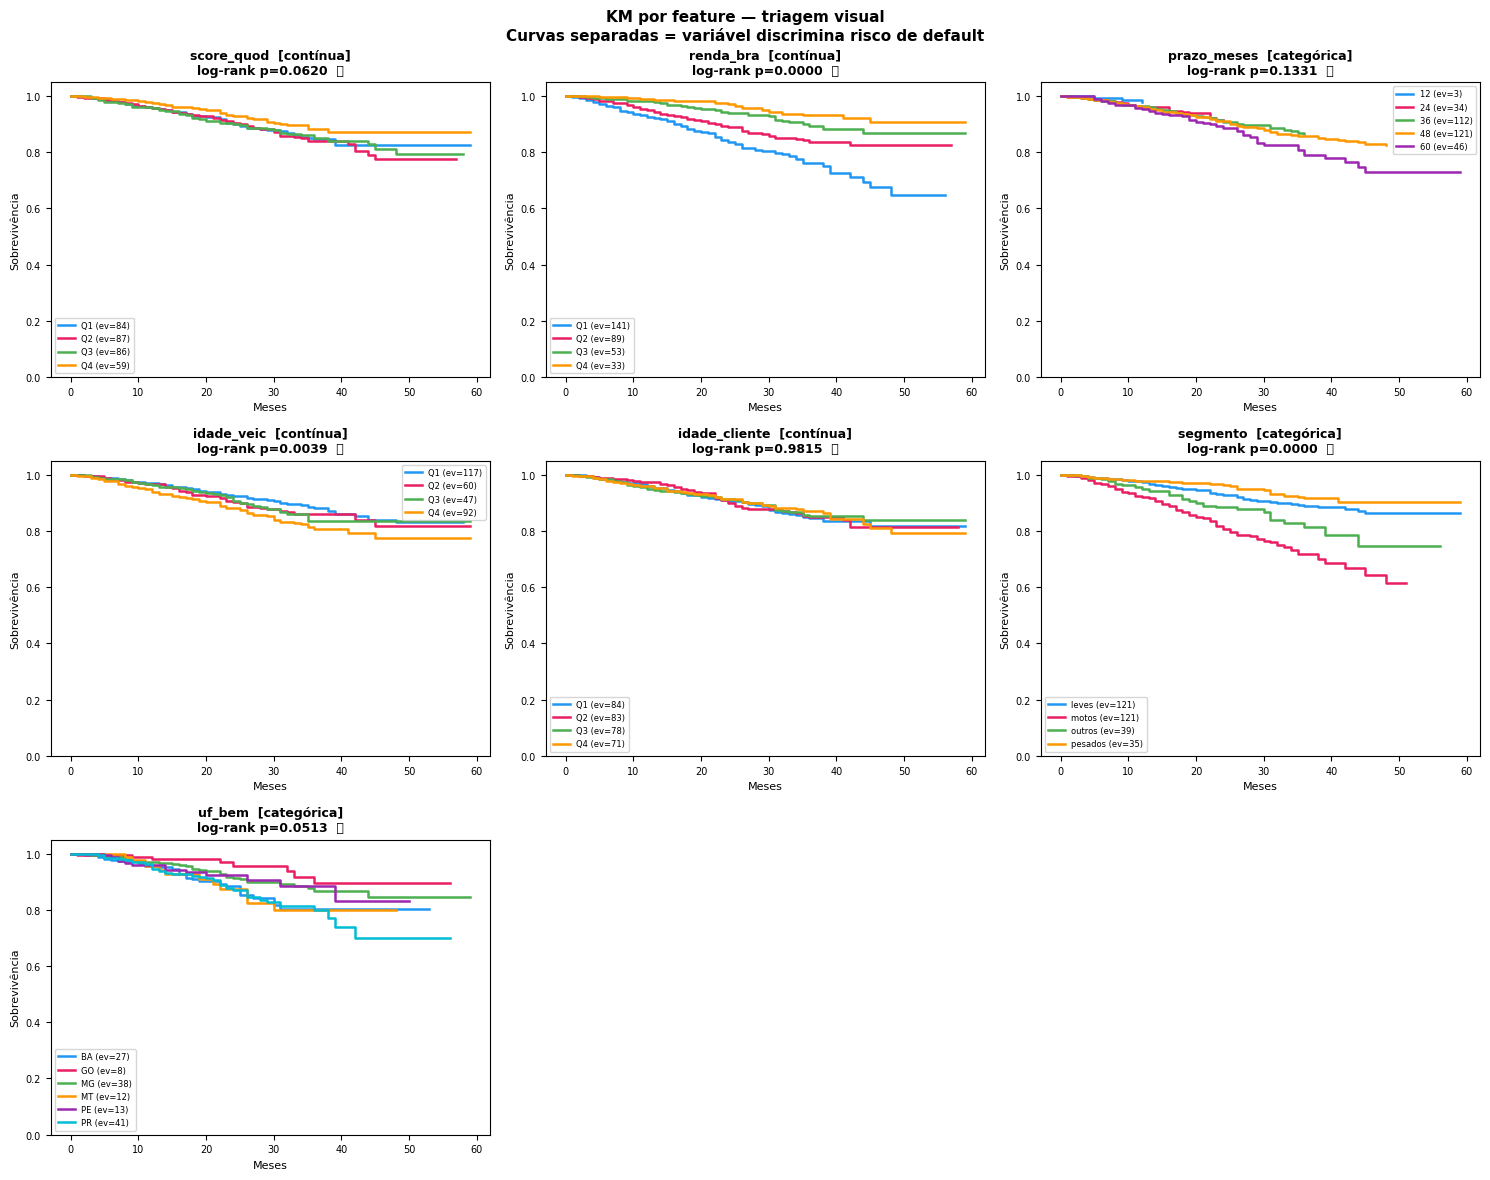


Ranking por p-value (menor = mais discriminativo):
      feature       tipo   pvalue  significativo
    renda_bra   contínua 0.000000           True
     segmento categórica 0.000000           True
   idade_veic   contínua 0.003858           True
       uf_bem categórica 0.051298          False
   score_quod   contínua 0.062020          False
  prazo_meses categórica 0.133080          False
idade_cliente   contínua 0.981540          False


In [34]:
def plot_km_by_feature(
    df: pd.DataFrame,
    features: list,
    time_col: str      = 't_default',
    event_col: str     = 'event_default',
    n_quantiles: int   = 4,
    ncols: int         = 3,
    figsize_per: tuple = (5, 4),
) -> pd.DataFrame:
    """
    Para cada feature contínua ou categórica:
      - Corta em n_quantiles (se numérica) ou usa os níveis direto (se categórica)
      - Plota KM por grupo
      - Calcula log-rank p-value

    Responde: "essa variável separa grupos com risco diferente?"

    Útil para triagem visual rápida antes do feature selection formal.
    Use o sample — não o dataset completo.

    Parameters
    ----------
    df          : DataFrame (sample)
    features    : lista de colunas a explorar
    time_col    : coluna de tempo
    event_col   : coluna de evento
    n_quantiles : número de grupos para variáveis contínuas
    ncols       : colunas no grid de plots
    figsize_per : tamanho de cada painel

    Returns
    -------
    DataFrame com feature, tipo, log-rank p-value e flag de significância
    """
    PALETTE = ['#2196F3','#E91E63','#4CAF50','#FF9800','#9C27B0','#00BCD4']

    nrows = int(np.ceil(len(features) / ncols))
    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(figsize_per[0] * ncols, figsize_per[1] * nrows)
    )
    axes = np.array(axes).flatten()

    rows = []
    for i, feat in enumerate(features):
        ax = axes[i]

        # Determina se é categórica ou numérica
        is_cat = df[feat].dtype == 'object' or df[feat].nunique() <= 6

        if is_cat:
            grupos = sorted(df[feat].unique())
            labels = grupos
            col_grp = df[feat]
            tipo = 'categórica'
        else:
            col_grp = pd.qcut(df[feat], q=n_quantiles,
                               labels=[f'Q{j+1}' for j in range(n_quantiles)],
                               duplicates='drop')
            grupos = col_grp.cat.categories.tolist()
            labels = grupos
            tipo = 'contínua'

        # Log-rank global
        try:
            lr  = multivariate_logrank_test(df[time_col], col_grp, df[event_col])
            pval = lr.p_value
        except Exception:
            pval = np.nan

        sig = '✅' if (not np.isnan(pval) and pval < 0.05) else '❌'

        # KM por grupo
        for grupo, color in zip(grupos, PALETTE):
            mask = col_grp == grupo
            if mask.sum() < 10:
                continue
            ev  = df.loc[mask, event_col].sum()
            kmf = KaplanMeierFitter(label=f'{grupo} (ev={ev})')
            kmf.fit(df.loc[mask, time_col],
                    event_observed=df.loc[mask, event_col])
            kmf.plot_survival_function(
                ax=ax, color=color,
                ci_show=False, linewidth=1.8,
            )

        pval_str = f'{pval:.4f}' if not np.isnan(pval) else 'N/A'
        ax.set_title(
            f'{feat}  [{tipo}]\n'
            f'log-rank p={pval_str}  {sig}',
            fontweight='bold', fontsize=9,
        )
        ax.set_xlabel('Meses', fontsize=8)
        ax.set_ylabel('Sobrevivência', fontsize=8)
        ax.set_ylim(0, 1.05)
        ax.legend(fontsize=6)
        ax.tick_params(labelsize=7)

        rows.append({
            'feature'      : feat,
            'tipo'         : tipo,
            'pvalue'       : round(pval, 6) if not np.isnan(pval) else np.nan,
            'significativo': pval < 0.05 if not np.isnan(pval) else False,
        })

    # Oculta painéis vazios
    for j in range(len(features), len(axes)):
        axes[j].set_visible(False)

    plt.suptitle(
        'KM por feature — triagem visual\n'
        'Curvas separadas = variável discrimina risco de default',
        fontsize=11, fontweight='bold',
    )
    plt.tight_layout()
    plt.show()

    result = pd.DataFrame(rows).sort_values('pvalue')
    print('\nRanking por p-value (menor = mais discriminativo):')
    print(result.to_string(index=False))
    return result


# Todas as features candidatas
FEATURES = ['score_quod', 'renda_bra', 'prazo_meses',
            'idade_veic', 'idade_cliente', 'segmento', 'uf_bem']

km_features = plot_km_by_feature(sample, features=FEATURES)

In [35]:
s


NameError: name 's' is not defined